In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import matplotlib.pyplot as plt
import numpy as np

In [47]:
from sim.camera import Camera
from sim.lens import Lens
from sim.optics import print_fov
from sim.frame import make_blank_frame, display_frame
from sim.render import RenderConfig, render, plot_render_stages
from sim.physics.stars import load_star_field

In [5]:
cam = Camera(nx=1920, ny=1080, pixel_um=2.9)
lens = Lens(focal_mm=16.0, f_number=1.4)
print_fov(cam, lens)

Sensor: 5.568 mm x 3.132 mm
FOV:    19.939 deg x 11.216 deg
Scale:  37.385 arcsec / px


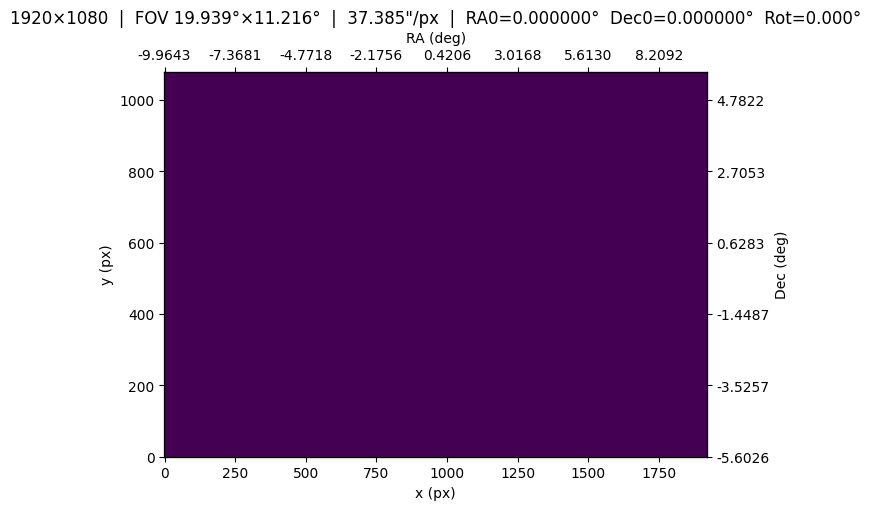

In [33]:
frame = make_blank_frame(cam, lens, ra0_deg=0.0, dec0_deg=0.0, rot_deg=0.0)
cfg = RenderConfig(exposure_s=0.2, sky_e_per_px_s=3, seed=0)

frame, res = render(frame, cfg, stars=None, return_intermediates=True)
display_frame(frame)

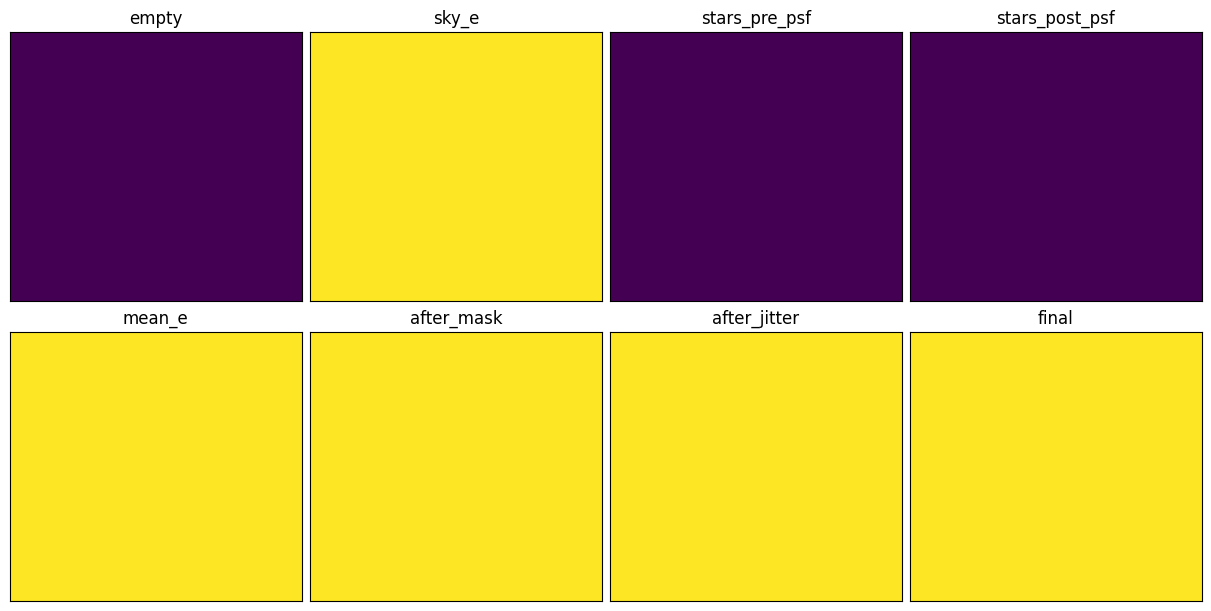

In [34]:
plot_render_stages(frame, res)

In [35]:
res

RenderResult(sky_e=array([[0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       ...,
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6]], dtype=float32), stars_e_pre_psf=array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), stars_e_post_psf=array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), mean_e=array([[0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
  

In [49]:
sf = load_star_field(r"sim/physics/starfields/2026-02-21-20-42-13-141665.csv")

print(sf)
print("Number of stars:", len(sf.ra_deg))
print("First 5 RA:", sf.ra_deg[:5])
print("First 5 Dec:", sf.dec_deg[:5])
print("First 5 mag:", sf.mag[:5])

StarField(ra_deg=array([43.2152059 , 43.23192274, 42.34009472, ..., 38.31500712,
       38.23053712, 45.06247884]), dec_deg=array([67.2610422 , 67.28292932, 67.20055984, ..., 72.79306683,
       72.84356205, 72.42783302]), mag=array([10.841185, 11.477264, 11.241699, ..., 10.358335, 10.709455,
       10.374672]), meta={'source': 'sim\\physics\\starfields\\2026-02-21-20-42-13-141665.csv'})
Number of stars: 2091
First 5 RA: [43.2152059  43.23192274 42.34009472 42.36222467 42.79482752]
First 5 Dec: [67.2610422  67.28292932 67.20055984 67.24970666 67.30214597]
First 5 mag: [10.841185 11.477264 11.241699 11.323478 11.561693]
